# Baseline Machine Learning Models

## Objective

Following the leakage analysis conducted in Notebook 1, this notebook develops text-based fake news detection models using only article titles and article content.

The goals are:

1. Establish baseline performance.
2. Compare classical machine learning methods.
3. Evaluate text representations using TF-IDF features.
4. Create benchmarks for future transformer-based experiments.

In [1]:
import pandas as pd
import numpy as np

import re
import string

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("clean_news.csv")

df.head()

,title,text,subject,date,label,article_length
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0,2893
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0,1898
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0,3597
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0,2774
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0,2346


## Text Construction

To maximize textual information available to the model, article titles and article bodies are combined into a single feature.

In [4]:
df["content"] = df["title"] + " " + df["text"]

## Text Preprocessing

The following preprocessing steps are applied:

- Lowercasing
- URL removal
- Punctuation removal
- Whitespace normalization

In [5]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    text = re.sub(r"\s+", " ", text)

    return text

In [6]:
df["content"] = df["content"].apply(clean_text)

## Train-Test Split

A stratified split is used to preserve class balance.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    df["content"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

## TF-IDF Feature Extraction

TF-IDF converts textual content into numerical vectors while preserving word importance.

In [8]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=10000,
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

## Logistic Regression

In [9]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train_tfidf,
    y_train
)

lr_pred = lr.predict(X_test_tfidf)

In [10]:
print(classification_report(
    y_test,
    lr_pred
))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4696
           1       0.99      0.99      0.99      4242

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



In [11]:
lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

lr_f1 = f1_score(
    y_test,
    lr_pred
)

print("Accuracy:", lr_accuracy)
print("F1:", lr_f1)

Accuracy: 0.9892593421347058
F1: 0.9887111947318908


## Multinomial Naive Bayes

In [12]:
nb = MultinomialNB()

nb.fit(
    X_train_tfidf,
    y_train
)

nb_pred = nb.predict(X_test_tfidf)

In [13]:
print(
    classification_report(
        y_test,
        nb_pred
    )
)

              precision    recall  f1-score   support

           0       0.95      0.94      0.95      4696
           1       0.94      0.95      0.94      4242

    accuracy                           0.95      8938
   macro avg       0.94      0.95      0.94      8938
weighted avg       0.95      0.95      0.95      8938



## Linear Support Vector Machine

In [14]:
svm = LinearSVC()

svm.fit(
    X_train_tfidf,
    y_train
)

svm_pred = svm.predict(X_test_tfidf)

In [15]:
print(
    classification_report(
        y_test,
        svm_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



## Model Comparison Table


In [16]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, svm_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, nb_pred),
        f1_score(y_test, svm_pred)
    ]
})

results

,Model,Accuracy,F1 Score
0,Logistic Regression,0.989259,0.988711
1,Naive Bayes,0.945066,0.942351
2,Linear SVM,0.996196,0.995993


## Confusion Matrix (Best Model)


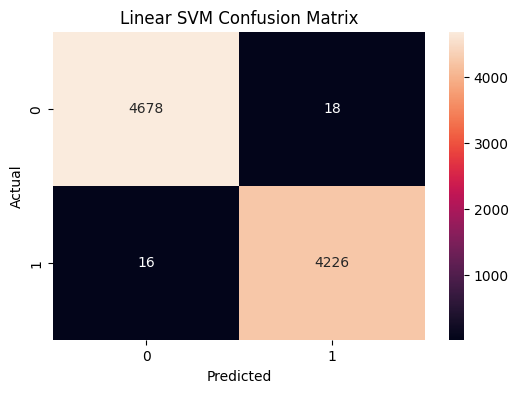

In [17]:
cm = confusion_matrix(
    y_test,
    svm_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Linear SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Conclusions

## Key Findings

- Subject and date metadata were excluded due to the severe label leakage identified in Notebook 1.
- TF-IDF representations successfully captured discriminative textual information from news articles.
- Classical machine learning models achieved strong performance on the dataset.
- Linear SVM emerged as the best-performing baseline model, achieving:
  - Accuracy: 99.62%
  - F1 Score: 99.60%
- Logistic Regression also performed competitively with an accuracy of 98.93%.
- Multinomial Naive Bayes achieved lower performance, suggesting that linear margin-based classifiers are better suited for this task.

## Discussion

Despite removing metadata features responsible for leakage, the textual content remains highly separable. The strong performance of Linear SVM indicates that classical NLP approaches provide a powerful baseline for fake news detection on this dataset.

## Next Step

Notebook 03 will evaluate transformer-based architectures, including DistilBERT, and compare them against these classical machine learning baselines.

In [18]:
pip install joblib

In [20]:
import os
import joblib

# Create folder if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save models
joblib.dump(lr, "models/logistic_regression.pkl")
joblib.dump(svm, "models/svm.pkl")
joblib.dump(vectorizer, "models/vectorizer.pkl")

['models/vectorizer.pkl']